In [68]:
title = "# Random variables and probability distributions: Exercises"
# Print title and setup TeX defs for both KaTeX and MathJax
import bayesian_stats_course_tools
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
bayesian_stats_course_tools.misc.display_markdown_and_setup_tex(title)

import matplotlib.style
matplotlib.style.use("bayesian_stats_course_tools.light")

# Random variables and probability distributions: Exercises

<!-- Define LaTeX macros -->
$\def\E{\operatorname{E}}$
$\def\Var{\operatorname{Var}}$
$\def\Cov{\operatorname{Cov}}$
$\def\dd{\mathrm{d}}$
$\def\ee{\mathrm{e}}$
$\def\Norm{\mathcal{N}}$
$\def\Uniform{\mathcal{U}}$
$\def\GP{\mathcal{GP}}$

<!-- MathJax needs them to be defined again for the non-inline environment -->
$$\def\E{\operatorname{E}}$$
$$\def\Var{\operatorname{Var}}$$
$$\def\Cov{\operatorname{Cov}}$$
$$\def\dd{\mathrm{d}}$$
$$\def\ee{\mathrm{e}}$$
$$\def\Norm{\mathcal{N}}$$
$$\def\Uniform{\mathcal{U}}$$
$$\def\GP{\mathcal{GP}}$$

### Exercises 1

Sample from the distribution with PDF
$$
    p(x) = \begin{cases}
                0 & x < 0 \\
                \frac{1}{2}\sin x & \text{otherwise} \\
                0 & x > \pi
            \end{cases}
$$
- Plot the PDF and CDF
- Sample from the distribution using invere transform sampling
- Compare the histogram of the samples to the PDF


In [40]:
def p(x):
    if x>0 and x<np.pi:
        return 0.5*np.sin(x)
    else:
        return 0
def cdf(x,dx):
    return np.cumsum(x)*dx

def inverse_sample(ys,n,max_p,dx): #my version of inverse sampling by looking at cdf, sampling 0,1 uniform, count nr of 
    # xs in a certain bin, where uniformly sampled points are for the first time larger than the cdf-> nr of points per bin
    # normalizing them with the sum(dx*nr of points per bin)=1 gives us the pdf but the suggested method in lecture is prolly more refined and covers edge cases
    samples=np.random.uniform(0,max_p,n)
    counts=np.zeros(ys.size)
    
    for i in range (0,len(samples)-1):
        j=0
        while samples[i]>ys[j] and j<len(samples)-1:
            j+=1
        counts[j]+=1
        continue
        
    return counts/(np.sum(dx*counts))

def inverse_sample_correct(n):
    samples=np.random.uniform(0,1,n)
    # print(samples)
    y=np.arccos(1-2*samples)
    return y

In [41]:
xs=np.arange(0,np.pi,np.pi/100)
dx=xs[1]-xs[0]
ys=np.ones(xs.size)
for i in range(0,len(xs)):
    ys[i]=p(xs[i]) 
cdfs=cdf(ys,dx)
max_p=np.max(cdfs)

In [42]:
a=inverse_sample(cdfs,10000,max_p,dx)

(array([0.08300902, 0.23384643, 0.35173863, 0.4454064 , 0.45735711,
        0.50386801, 0.44056151, 0.36756525, 0.24870408, 0.09786667]),
 array([0.00939626, 0.31900115, 0.62860604, 0.93821093, 1.24781583,
        1.55742072, 1.86702561, 2.17663051, 2.4862354 , 2.79584029,
        3.10544519]),
 <BarContainer object of 10 artists>)

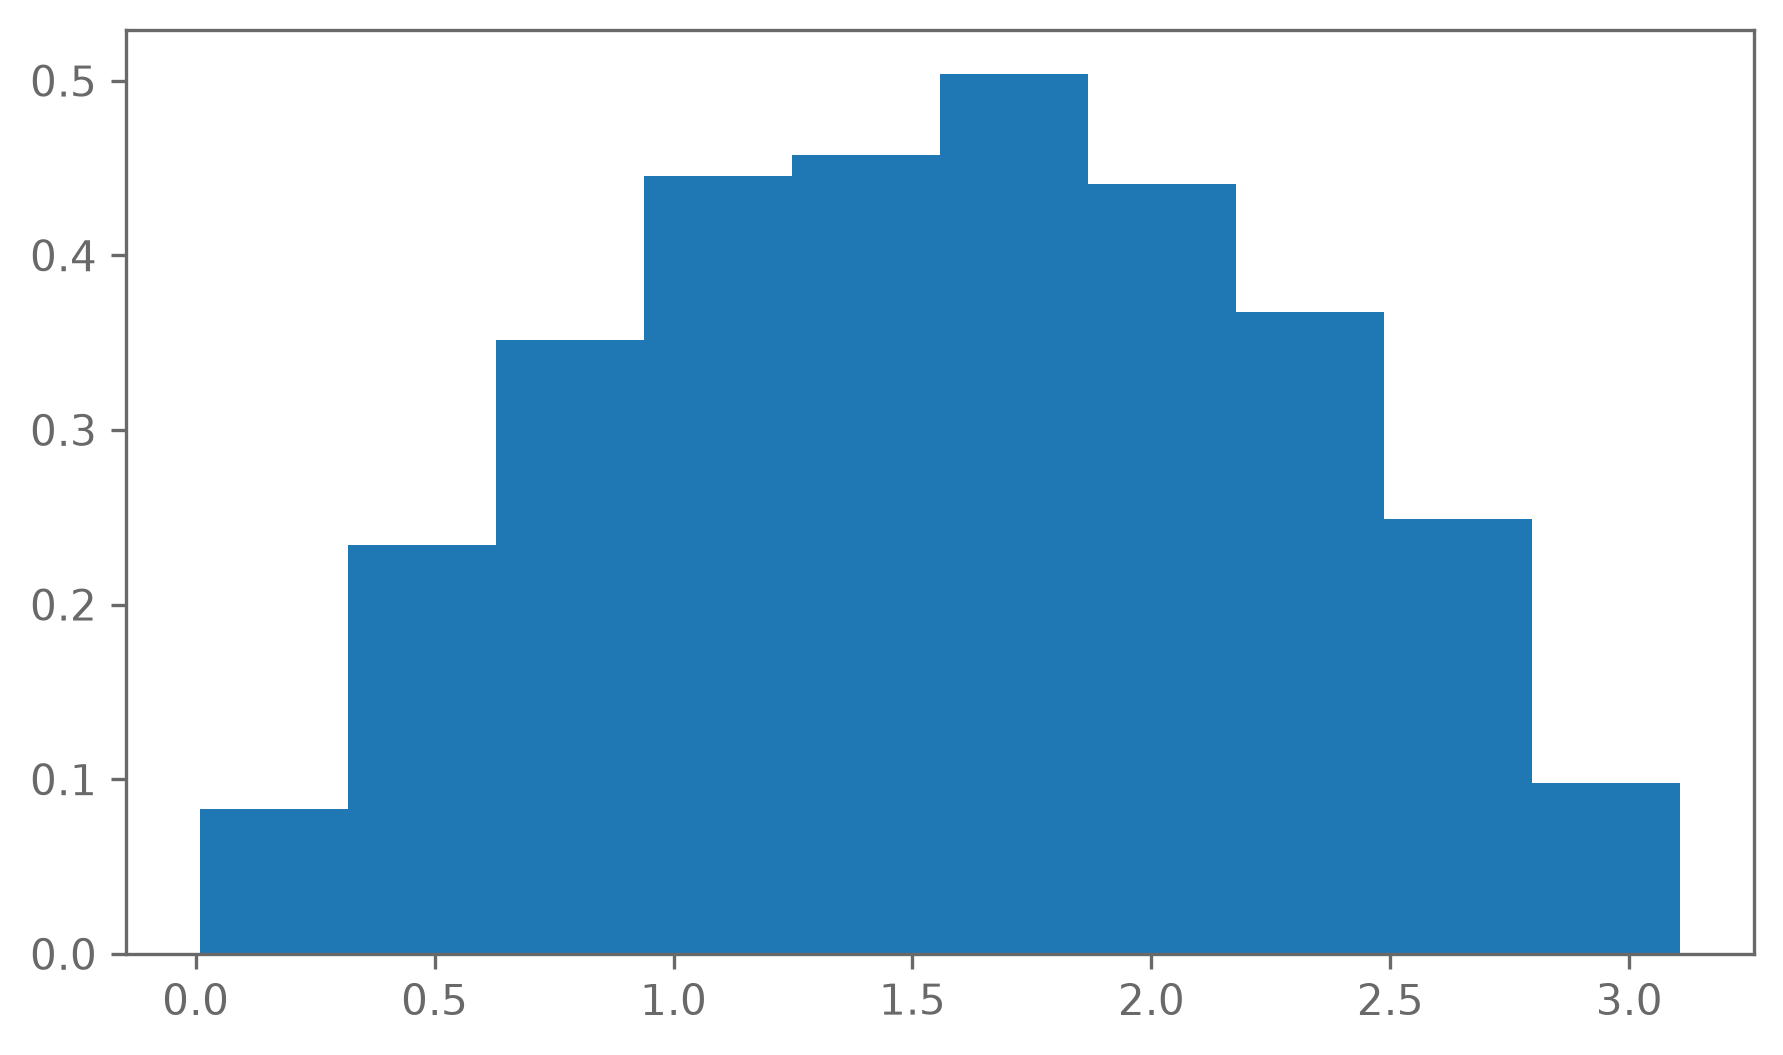

In [47]:
b=inverse_sample_correct(10000)
plt.hist(b,density=True)

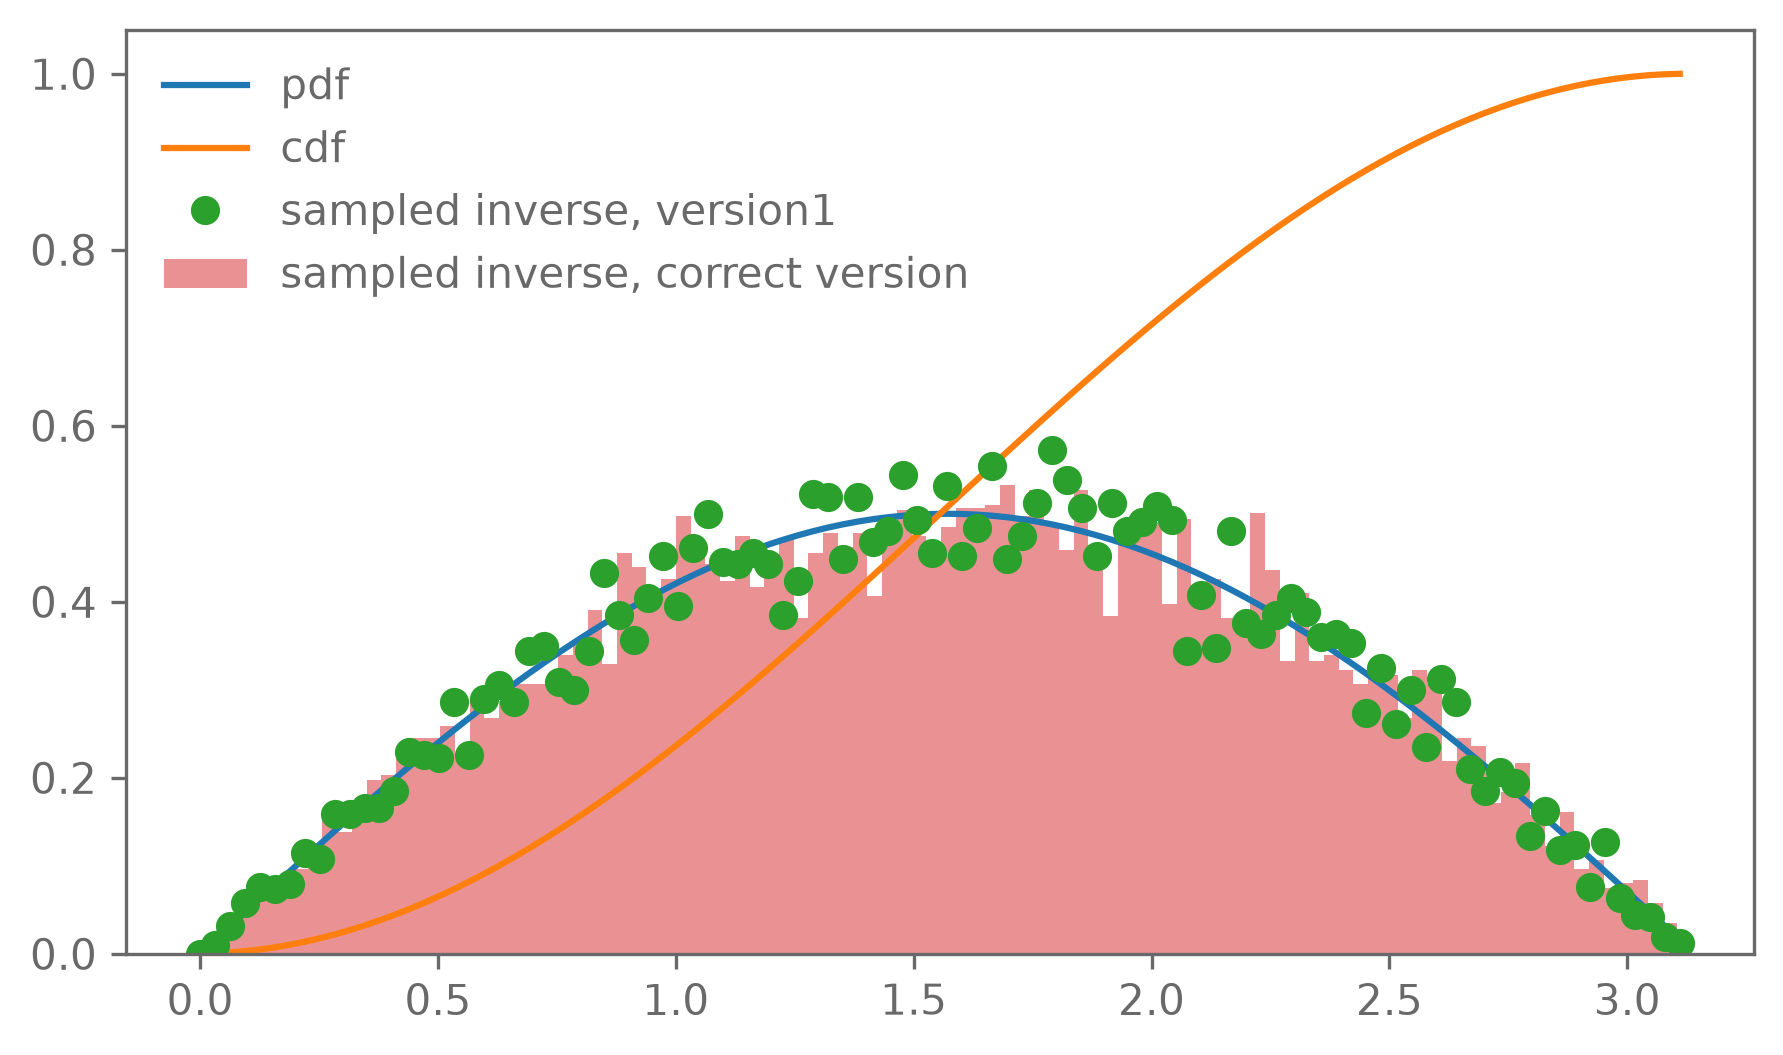

In [49]:
plt.plot(xs,ys, label="pdf")
plt.plot(xs, cdfs, label="cdf")
plt.plot(xs, a, "o", label="sampled inverse, version1")
plt.hist(b,bins=100,density=True, label="sampled inverse, correct version", alpha=0.5)
plt.legend()


### Exercise 2

Show the expressions for the mean and variance:

- For some constant $a$: $\E[x + a] = \mu + a$
- For some constant $c$: $\E[cx] = c\mu$

- $\sigma[x] = E[(x - E[x])^2] = E[x^2] - E[x]^2$
- For some constant $a$: $\Var[x + a] = \sigma^2$
- For some constant $c$: $\Var[cx] = c^2\sigma^2$

### Exercises 3

- Confirm by simulation that the probability of $k$ out of $n$ iid $X_i\sim\ U(0,1)$ being in a small interval $\Delta x$ follows a Poisson distribution.
- Derive the Poisson distribution from the binomial distribution.

In [126]:
def poisson(k,lamb):
    return lamb**int(k) /sc.special.factorial(int(k)) *np.exp(-lamb)

def sim(n_tries,n=1000):
    nrs=np.zeros(n_tries)
    for i in range (0,n_tries):
        x=np.random.uniform(0,1,n)
        dx_low=np.random.random(1)
        mask= (x>=dx_low) & (x<=dx_low+10/n)
        counts=len(x[mask])
        nrs[i]=counts
    return nrs

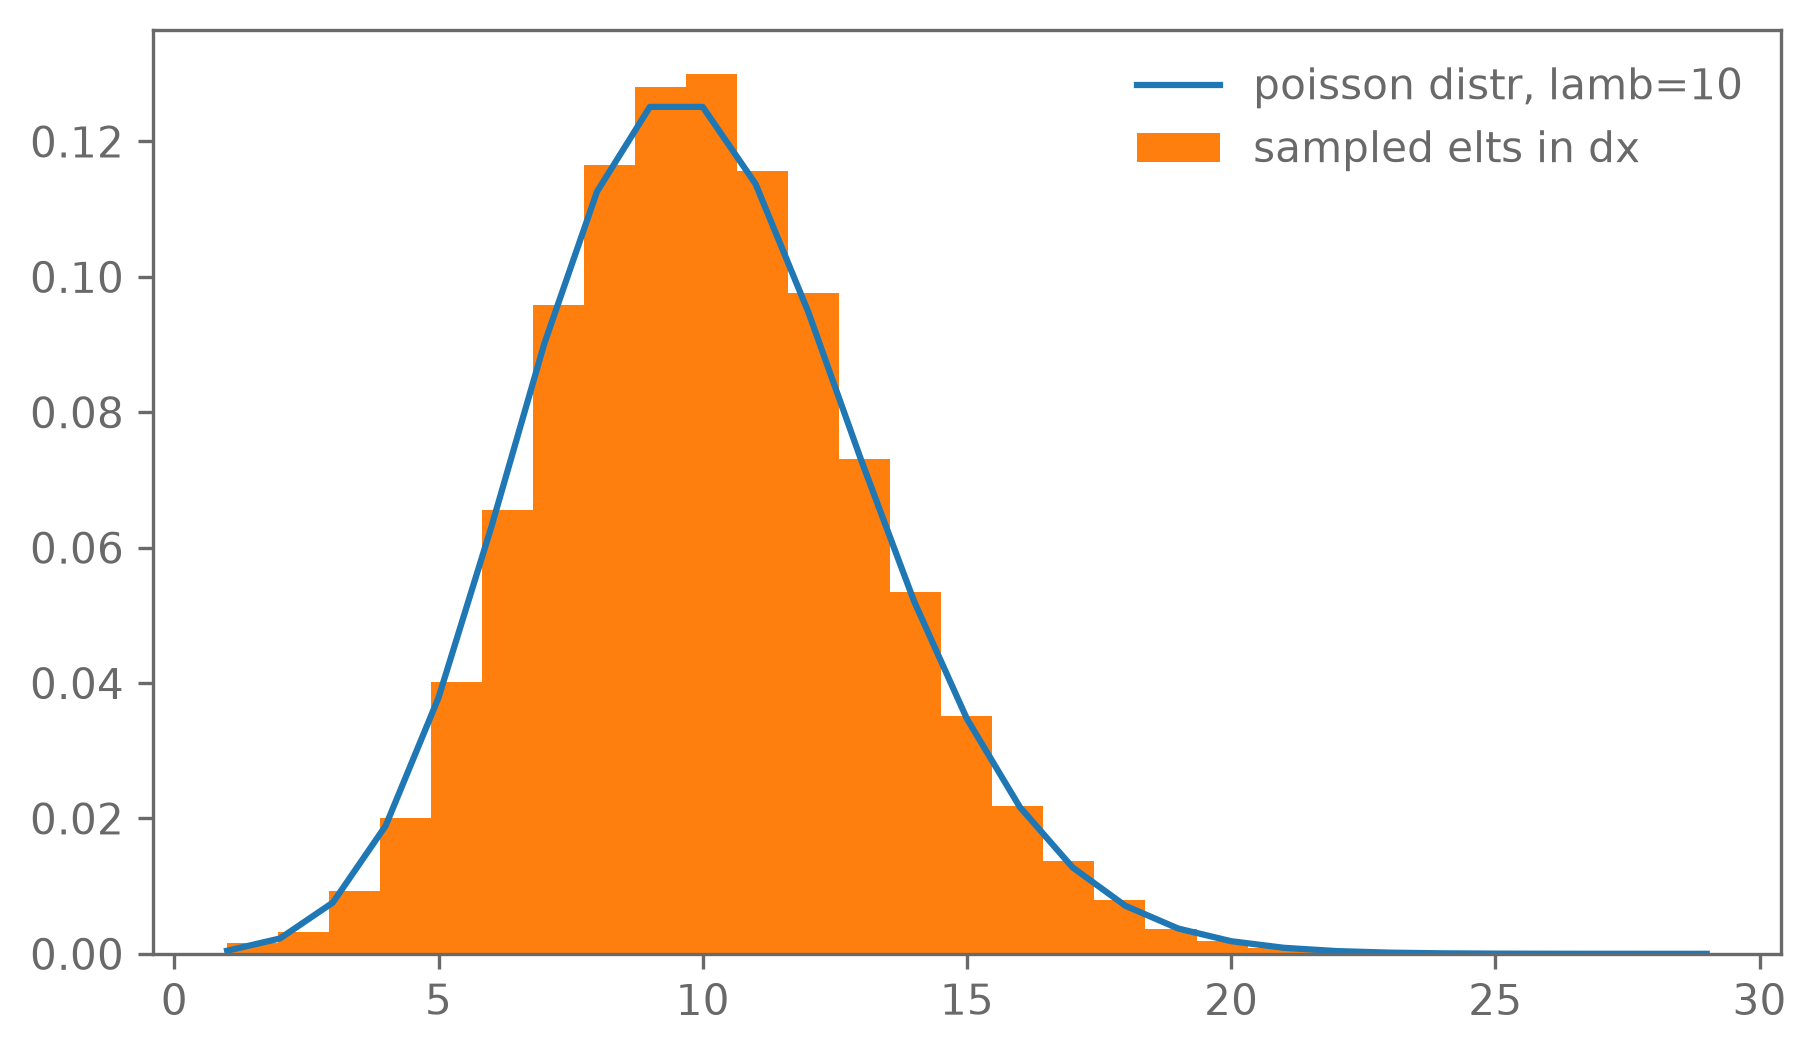

In [129]:
n=1000
lamb=10
arr=[poisson(elt,lamb) for elt in np.arange(1,30,1)]
plt.plot(np.arange(1,30,1),arr, label="poisson distr, lamb=10")
plt.hist(sim(100000,n=1000),bins=29,density=True,range=(1,29), label="sampled elts in dx")
plt.legend()

### Exercises 4

- Make plots of the PDFs of the distributions we covered so far, varying their parameters
- Compute the distribution of the sum of two independent Gaussian RVs.
- What is the distribution of the sum of two independent RVs $X\sim f$ and $Y\sim g$?
- Derive the PDF of the $\chi^2_{\nu=1}$ distribution
- Bonus:
    - What is the product of two independent RVs $U$ and $V$?
    - Compute the distribution of the ratio of two Gaussian RVs.
